# Football Player Scouting & Recruitment Recommendation System

## 02 — Position Analysis

This notebook analyzes the characteristics associated with each football
position.

### Objectives

- Load the cleaned player dataset
- Normalize scouting attributes
- Construct higher-level ability groups
- Compare player profiles by position
- Analyze correlations between attributes
- Measure position distinctiveness
- Define transparent position-specific scouting weights

The goal is not to reproduce EA's overall rating.

Instead, the analysis is used to construct an interpretable scouting
profile for each position.

In [21]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import add_age
from src.features import (
    ABILITY_GROUPS,
    INDIVIDUAL_ABILITIES,
    normalize_attributes,
    create_ability_features,
)
from src.scoring import POSITION_WEIGHTS

In [22]:
CLEANED_DATA_PATH = PROJECT_ROOT / "Data" / "players_cleaned.csv"

df = pd.read_csv(
    CLEANED_DATA_PATH,
    parse_dates=["birthdate"]
)

print(df.shape)
df.head()

(19789, 57)


,player_id,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,gender,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,eligible_positions,age
0,227203,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,Women's Football,...,60,82,64,15,17,11,15,10,CM CAM ST,32
1,231747,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,Men's Football,...,15,34,24,13,5,7,11,6,ST LW,27
2,239085,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,Men's Football,...,42,47,33,7,14,13,11,7,ST,26
3,192119,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,...,20,18,16,87,89,78,90,90,GK,34
4,202126,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,Men's Football,...,46,44,42,8,10,11,14,11,ST,33


In [23]:
df_normalized = normalize_attributes(df)
df_normalized = create_ability_features(df_normalized)

ability_features = (
    list(ABILITY_GROUPS.keys())
    + INDIVIDUAL_ABILITIES
    + ["stamina"]
)

print(f"Number of ability features: {len(ability_features)}")

Number of ability features: 23


In [24]:
position_means = (
    df_normalized
    .groupby("position")[ability_features]
    .mean()
)

position_means.round(3)

,pace,dribbling_control,agility,passing_technique,shooting_power,defending,tackling,aerial,physical,attacking_finishing,...,mentality_positioning,mentality_composure,movement_reactions,mentality_aggression,skill_moves,weak_foot,mentality_penalties,skill_curve,skill_fk_accuracy,stamina
position,,,,,,,,,,,,,,,,,,,,,
CAM,0.669,0.713,0.714,0.671,0.620,0.447,0.449,0.484,0.525,0.641,...,0.670,0.628,0.535,0.513,0.534,0.545,0.573,0.633,0.589,0.622
CB,0.554,0.539,0.468,0.575,0.355,0.712,0.707,0.688,0.675,0.313,...,0.370,0.551,0.523,0.669,0.259,0.441,0.371,0.359,0.312,0.634
CDM,0.576,0.663,0.616,0.676,0.551,0.699,0.687,0.581,0.649,0.501,...,0.566,0.604,0.548,0.678,0.338,0.499,0.479,0.529,0.487,0.704
CM,0.620,0.692,0.666,0.687,0.597,0.631,0.628,0.526,0.604,0.587,...,0.646,0.609,0.551,0.611,0.404,0.515,0.515,0.579,0.543,0.694
GK,0.237,0.104,0.247,0.204,0.210,0.086,0.065,0.241,0.306,0.062,...,0.063,0.294,0.459,0.162,0.000,0.372,0.090,0.070,0.074,0.160
LB,0.703,0.645,0.658,0.588,0.461,0.667,0.669,0.577,0.608,0.441,...,0.573,0.549,0.512,0.606,0.354,0.448,0.416,0.566,0.452,0.692
LM,0.758,0.699,0.732,0.602,0.597,0.382,0.380,0.507,0.537,0.633,...,0.654,0.584,0.501,0.472,0.536,0.530,0.552,0.602,0.522,0.630
LW,0.760,0.708,0.719,0.587,0.617,0.308,0.309,0.501,0.517,0.655,...,0.659,0.586,0.487,0.440,0.538,0.542,0.567,0.604,0.518,0.597
RB,0.703,0.637,0.653,0.582,0.444,0.665,0.669,0.581,0.613,0.439,...,0.567,0.548,0.508,0.613,0.342,0.484,0.414,0.537,0.408,0.693


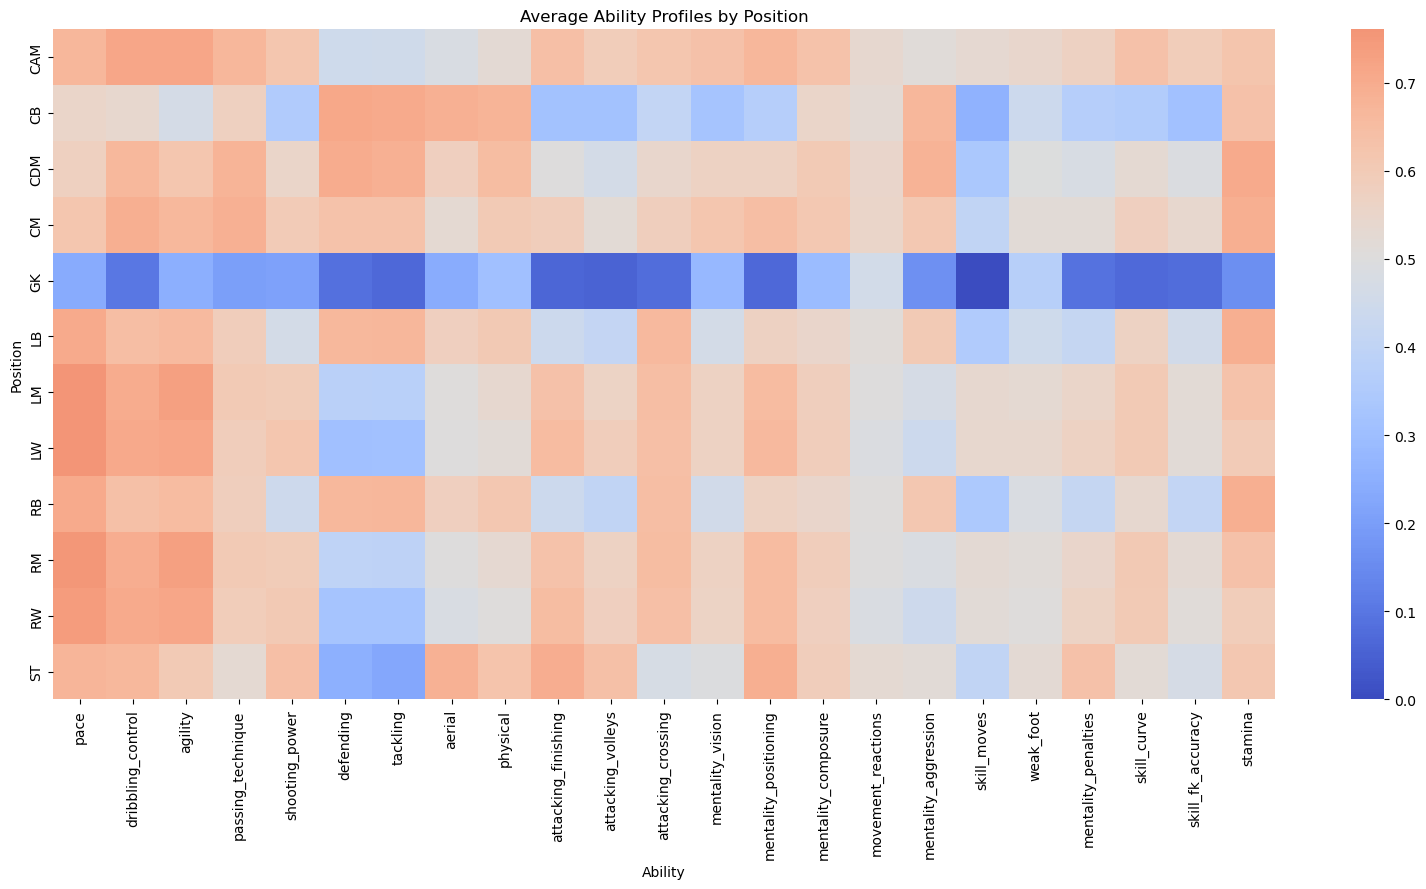

In [25]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    position_means,
    cmap="coolwarm",
    center=0.5
)

plt.title("Average Ability Profiles by Position")
plt.xlabel("Ability")
plt.ylabel("Position")
plt.tight_layout()
plt.show()

## Attribute correlation

Many raw attributes measure closely related abilities.

For example:

- acceleration and sprint speed
- standing and sliding tackle
- awareness and interceptions
- short and long passing
- goalkeeper attributes

Highly correlated attributes can dominate a scoring system if they are
simply added independently.

For this reason, related attributes are grouped into higher-level abilities.

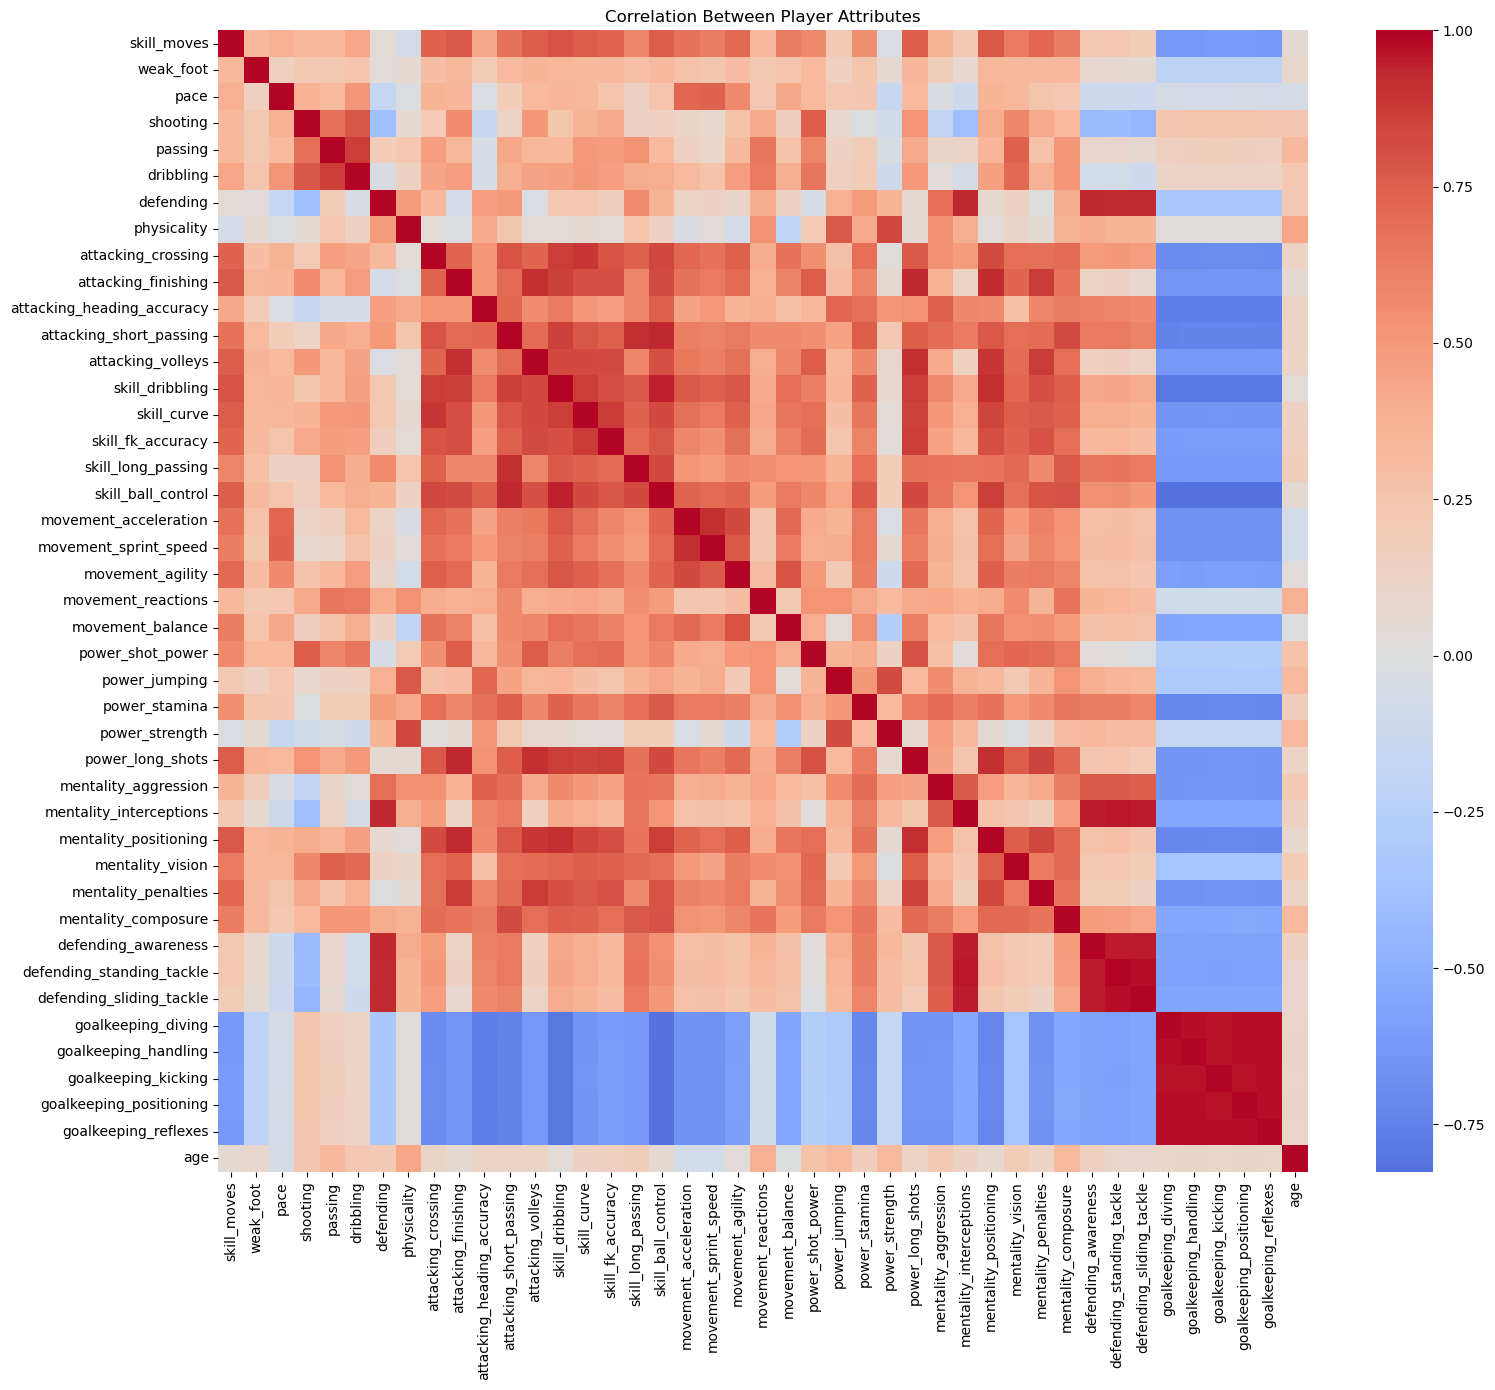

In [26]:
raw_scouting_attributes = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in ["player_id", "overall_rating"]
]

correlation_matrix = df[raw_scouting_attributes].corr()

plt.figure(figsize=(16, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Player Attributes")
plt.tight_layout()
plt.show()

In [27]:
correlation_pairs = [
    ("movement_acceleration", "movement_sprint_speed"),
    ("skill_dribbling", "skill_ball_control"),
    ("attacking_short_passing", "skill_long_passing"),
    ("power_shot_power", "power_long_shots"),
    ("mentality_interceptions", "defending_awareness"),
    ("defending_standing_tackle", "defending_sliding_tackle"),
    ("attacking_heading_accuracy", "power_jumping"),
    ("power_strength", "power_stamina"),
    ("movement_agility", "movement_balance"),
]

for feature_1, feature_2 in correlation_pairs:
    correlation = df[[feature_1, feature_2]].corr().iloc[0, 1]
    print(f"{feature_1} ↔ {feature_2}: {correlation:.3f}")

movement_acceleration ↔ movement_sprint_speed: 0.914
skill_dribbling ↔ skill_ball_control: 0.947
attacking_short_passing ↔ skill_long_passing: 0.915
power_shot_power ↔ power_long_shots: 0.798
mentality_interceptions ↔ defending_awareness: 0.957
defending_standing_tackle ↔ defending_sliding_tackle: 0.978
attacking_heading_accuracy ↔ power_jumping: 0.720
power_strength ↔ power_stamina: 0.321
movement_agility ↔ movement_balance: 0.787


## Position distinctiveness

A position's distinctiveness is measured by comparing its average ability
profile against the average profile of all players outside that position.

Positive values indicate abilities that are relatively characteristic
of the position.

This is used as an analytical guide rather than as an automatic source
of recommendation weights.

In [28]:
position_distinctiveness = {}

for position in df_normalized["position"].unique():

    position_players = df_normalized[
        df_normalized["position"] == position
    ]

    other_players = df_normalized[
        df_normalized["position"] != position
    ]

    position_avg = position_players[ability_features].mean()
    others_avg = other_players[ability_features].mean()

    position_distinctiveness[position] = position_avg - others_avg

distinctiveness_df = pd.DataFrame(
    position_distinctiveness
).T

distinctiveness_df.round(3)

,pace,dribbling_control,agility,passing_technique,shooting_power,defending,tackling,aerial,physical,attacking_finishing,...,mentality_positioning,mentality_composure,movement_reactions,mentality_aggression,skill_moves,weak_foot,mentality_penalties,skill_curve,skill_fk_accuracy,stamina
CM,0.016,0.118,0.096,0.145,0.119,0.161,0.166,-0.028,0.034,0.126,...,0.140,0.069,0.040,0.087,0.065,0.039,0.074,0.120,0.143,0.110
ST,0.077,0.093,0.023,-0.036,0.170,-0.278,-0.298,0.155,0.060,0.255,...,0.197,0.045,0.016,-0.020,0.064,0.049,0.215,0.055,0.064,0.020
GK,-0.416,-0.545,-0.376,-0.400,-0.318,-0.455,-0.469,-0.349,-0.302,-0.466,...,-0.516,-0.286,-0.065,-0.419,-0.390,-0.122,-0.405,-0.454,-0.385,-0.492
CDM,-0.033,0.081,0.037,0.126,0.064,0.227,0.223,0.032,0.081,0.027,...,0.047,0.061,0.034,0.156,-0.009,0.019,0.031,0.060,0.077,0.116
RM,0.158,0.113,0.158,0.044,0.109,-0.097,-0.095,-0.055,-0.042,0.163,...,0.137,0.039,-0.019,-0.051,0.189,0.032,0.103,0.142,0.113,0.040
CAM,0.067,0.133,0.141,0.118,0.135,-0.046,-0.035,-0.072,-0.052,0.175,...,0.156,0.085,0.020,-0.023,0.199,0.068,0.130,0.170,0.184,0.026
RW,0.139,0.117,0.137,0.030,0.117,-0.171,-0.163,-0.072,-0.070,0.178,...,0.137,0.033,-0.033,-0.092,0.174,0.022,0.116,0.131,0.099,-0.006
CB,-0.064,-0.059,-0.139,0.019,-0.167,0.271,0.275,0.167,0.123,-0.199,...,-0.186,0.004,0.008,0.164,-0.107,-0.049,-0.096,-0.140,-0.128,0.045
LW,0.158,0.123,0.140,0.028,0.128,-0.186,-0.177,-0.051,-0.059,0.183,...,0.141,0.039,-0.030,-0.097,0.196,0.063,0.120,0.133,0.103,0.000
LB,0.104,0.062,0.083,0.031,-0.034,0.191,0.202,0.028,0.036,-0.038,...,0.055,0.001,-0.005,0.076,0.008,-0.036,-0.036,0.100,0.039,0.102


In [29]:
for position in ["GK", "CB", "CDM", "CM", "CAM", "ST"]:

    print(f"\n### {position}")

    print(
        distinctiveness_df
        .loc[position]
        .sort_values(ascending=False)
        .head(8)
        .round(3)
    )


### GK
movement_reactions    -0.065
weak_foot             -0.122
mentality_vision      -0.218
mentality_composure   -0.286
physical              -0.302
shooting_power        -0.318
aerial                -0.349
agility               -0.376
Name: GK, dtype: float64

### CB
tackling                0.275
defending               0.271
aerial                  0.167
mentality_aggression    0.164
physical                0.123
stamina                 0.045
passing_technique       0.019
movement_reactions      0.008
Name: CB, dtype: float64

### CDM
defending               0.227
tackling                0.223
mentality_aggression    0.156
passing_technique       0.126
stamina                 0.116
mentality_vision        0.103
dribbling_control       0.081
physical                0.081
Name: CDM, dtype: float64

### CM
tackling                 0.166
mentality_vision         0.162
defending                0.161
passing_technique        0.145
skill_fk_accuracy        0.143
mentality_positioning   

## Position-specific scouting weights

The final weights are manually defined using:

1. Football logic
2. Position distinctiveness
3. Avoidance of redundant attribute counting
4. Interpretability

The weights are transparent and can later be customized according to
a club's recruitment priorities.

In [30]:
for position, weights in POSITION_WEIGHTS.items():

    print(f"\n{position}")

    for ability, weight in weights.items():
        print(f"  {ability}: {weight:.2f}")

    print("  Total:", sum(weights.values()))


GK
  goalkeeping: 1.00
  Total: 1.0

CB
  defending: 0.30
  tackling: 0.30
  aerial: 0.15
  physical: 0.12
  pace: 0.08
  passing_technique: 0.05
  Total: 1.0

CDM
  defending: 0.25
  tackling: 0.20
  passing_technique: 0.18
  vision: 0.12
  physical: 0.10
  aggression: 0.08
  dribbling_control: 0.07
  Total: 1.0

CM
  passing_technique: 0.20
  vision: 0.15
  dribbling_control: 0.15
  defending: 0.12
  tackling: 0.10
  shooting_power: 0.10
  finishing: 0.08
  positioning: 0.05
  agility: 0.05
  Total: 1.0

CAM
  dribbling_control: 0.18
  vision: 0.15
  skill_moves: 0.12
  finishing: 0.12
  passing_technique: 0.10
  shooting_power: 0.08
  positioning: 0.08
  agility: 0.07
  curve: 0.05
  composure: 0.05
  Total: 1.0

ST
  finishing: 0.25
  shooting_power: 0.15
  positioning: 0.15
  aerial: 0.12
  dribbling_control: 0.08
  pace: 0.08
  physical: 0.07
  skill_moves: 0.05
  composure: 0.05
  Total: 1.0

LW
  dribbling_control: 0.20
  pace: 0.18
  skill_moves: 0.15
  finishing: 0.12
  agil

## Conclusion

The analysis shows that different positions require substantially
different ability profiles.

Rather than relying on EA's overall rating, the scouting system will
therefore evaluate players using position-specific weighted profiles.

These weights provide the baseline recommendation model used in the
next notebook.